<a href="https://colab.research.google.com/github/marianamq-a11y/Estatistica-mariana/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tarefa 4 - Análise de quartis e boxplot

#Nomes:
      Nayara Penati- 15677365

      Mariana Lopes Marques- 14596593

      Lais Zanquettin- 14586772

# Tarefa 4 — Quartis e Boxplot

## Objetivo

Aplicar os conceitos de quartis, mediana, distância interquartil e boxplot a uma base de dados real da área de Ciências dos Alimentos, analisando o teor de proteína de alimentos da categoria leite e derivados.

## Fonte dos dados

Os dados utilizados foram obtidos da **Tabela Brasileira de Composição de Alimentos (TACO)**, na categoria **Leite e derivados**, considerando os alimentos prontos para o consumo.

A variável analisada foi o **teor de proteína (g/100 g)**.

Fonte: Tabela Brasileira de Composição de Alimentos (TACO).

## Fundamentação teórica

Para a análise dos dados, foram utilizados os conceitos de mediana, quartis, distância interquartil e boxplot apresentados por Bussab.

### Mediana

A mediana é uma medida que, considerando os dados ordenados, deixa metade das observações abaixo dela e metade acima dela. Quando o número de observações é par, a mediana é obtida pela média dos dois valores centrais.

### Quartis

Os quartis são quantis que dividem os dados em quatro partes. O primeiro quartil (Q1) corresponde ao quantil de ordem 0,25, o segundo quartil (Q2) corresponde ao quantil de ordem 0,50 e coincide com a mediana, e o terceiro quartil (Q3) corresponde ao quantil de ordem 0,75.

### Distância interquartil

A distância interquartil é calculada pela diferença entre o terceiro e o primeiro quartil:

$$
d_q = Q_3 - Q_1
$$

Essa medida representa a distância entre os quartis que delimitam os 50% centrais das observações.

### Boxplot e observações atípicas

O boxplot é uma representação gráfica baseada nos quartis e na mediana. Para identificar observações discrepantes ou atípicas, são calculados os limites inferior e superior:

$$
LI = Q_1 - 1,5d_q
$$

$$
LS = Q_3 + 1,5d_q
$$

Observações abaixo do limite inferior ou acima do limite superior são consideradas observações discrepantes ou atípicas.

**Referência:** BUSSAB, Wilton de Oliveira; MORETTIN, Pedro Alberto. Estatística Básica. 8. ed. São Paulo: Saraiva, 2013.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
url = "https://raw.githubusercontent.com/marianamq-a11y/Estatistica-mariana/main/tarefa4.xlsx"

dados = pd.read_excel(url)

dados

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Leite e derivados,NaN,Proteina (g/100g)
1,1,"Bebida láctea, pêssego",2.133333
2,2,Creme de Leite,1.507807
3,3,"Iogurte, natural",4.063333
4,4,"Iogurte, natural, desnatado",3.83438
5,5,"Iogurte, sabor abacaxi",*
6,6,"Iogurte, sabor morango",2.71
7,7,"Iogurte, sabor pêssego",2.53
8,8,"Leite, condensado",7.67
9,9,"Leite, de cabra",3.070907


In [ ]:
dados = dados.iloc[1:25, :3]

# Renomeando nome das colunas
dados.columns = ["id", "Alimento", "Proteina"]

dados["Proteina"] = pd.to_numeric(dados["Proteina"], errors="coerce")
dados

,id,Alimento,Proteina
1,1,"Bebida láctea, pêssego",2.133333
2,2,Creme de Leite,1.507807
3,3,"Iogurte, natural",4.063333
4,4,"Iogurte, natural, desnatado",3.834380
5,5,"Iogurte, sabor abacaxi",NaN
6,6,"Iogurte, sabor morango",2.710000
7,7,"Iogurte, sabor pêssego",2.530000
8,8,"Leite, condensado",7.670000
9,9,"Leite, de cabra",3.070907
10,10,"Leite, de vaca, achocolatado",2.099020


In [ ]:
proteina = dados["Proteina"].dropna()

proteina

,Proteina
1,2.133333
2,1.507807
3,4.063333
4,3.834380
6,2.710000
7,2.530000
8,7.670000
9,3.070907
10,2.099020
11,34.690000


Q1: 2.71
Mediana (Q2): 7.67
Q3: 21.21
AIQ (IQR): 18.50


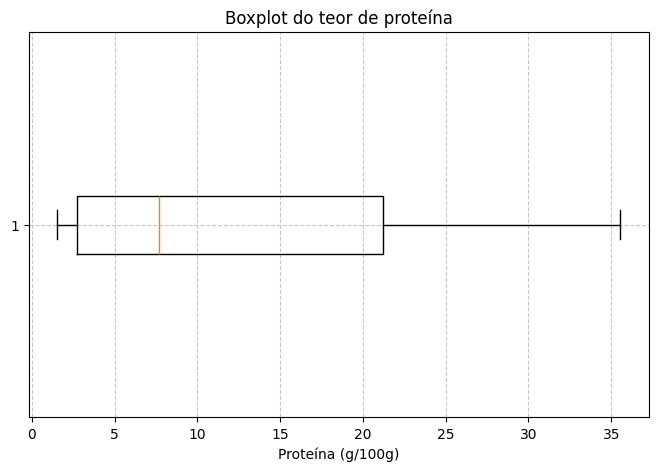

In [ ]:
variable_name = 'Proteina (g/100g)'
# Cálculo dos quartis
q1 = dados["Proteina"].quantile(0.25)
q2 = dados["Proteina"].quantile(0.50)
q3 = dados["Proteina"].quantile(0.75)
iqr = q3 - q1

print(f"Q1: {q1:.2f}")
print(f"Mediana (Q2): {q2:.2f}")
print(f"Q3: {q3:.2f}")
print(f"AIQ (IQR): {iqr:.2f}")

# Boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(dados["Proteina"].dropna(), vert=False)
plt.title("Boxplot do teor de proteína")
plt.xlabel("Proteína (g/100g)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### Interpretação do boxplot


O boxplot representa a distribuição dos teores de proteína dos alimentos de leite e derivados analisados. A mediana foi de 7,67 g/100 g, indicando que metade das observações apresenta valores de proteína inferiores ou iguais a esse valor, enquanto a outra metade apresenta valores superiores ou iguais.

O primeiro quartil ($Q1$) foi de 2,71 g/100 g e o terceiro quartil ($Q_3$) foi de 21,21 g/100 g. Portanto, os 50% centrais dos valores de proteína estão aproximadamente entre 2,71 e 21,21 g/100 g.

Conseguimos ver uma variação considerável no teor de proteína entre os alimentos analisados. Essa variação está relacionada à diversidade dos produtos incluídos na base, que apresenta alimentos com diferentes características e composições, como bebidas lácteas, leites e queijos.

Pelo critério de 1,5 vezes a distância interquartil, não foram identificadas observações atípicas na base analisada.

A análise dos dados de teor de proteína dos alimentos do grupo “Leite e derivados” da TACO apresentou primeiro quartil ($Q_1$) de 2,71 g/100 g, mediana de 7,67 g/100 g e terceiro quartil ($Q_3$) de 21,21 g/100 g. O intervalo interquartil (AIQ) foi de 18,50 g/100 g. Os limites inferior e superior calculados foram de -25,04 g/100 g e 48,96 g/100 g, respectivamente. Como nenhum dos valores analisados ultrapassou esses limites, não foram identificados valores discrepantes (outliers) pelo critério de $1{,}5 \times AIQ$. O boxplot permite visualizar a distribuição dos valores de proteína e a dispersão dos dados.

### Como determinar se há observações atípicas?

Para determinar se há observações atípicas, calcula-se inicialmente a distância interquartil, dada por $d_q = Q_3 - Q_1$. Em seguida, são determinados o limite inferior e o limite superior, utilizando as expressões $LI = Q_1 - 1{,}5 d_q$ e $LS = Q_3 + 1{,}5 d_q$. As observações que apresentam valores abaixo do limite inferior ou acima do limite superior são consideradas observações discrepantes ou atípicas.

Para os dados analisados, o limite inferior foi de -25,04 g/100 g e o limite superior foi de 48,96 g/100 g. Como nenhum dos valores de proteína ficou fora desses limites, não foram identificadas observações atípicas na base analisada.

## Referências

BUSSAB, Wilton de Oliveira; MORETTIN, Pedro Alberto. *Estatística Básica*. 8. ed. São Paulo: Saraiva, 2013.

UNIVERSIDADE ESTADUAL DE CAMPINAS. Núcleo de Estudos e Pesquisas em Alimentação. *Tabela brasileira de composição de alimentos – TACO*. 4. ed. rev. e ampl. Campinas: NEPA-UNICAMP, 2011.